# Hot subdwarf stars

This notebook is used to prepare the GO proposal for hot subdwarf stars.

- Author: Nicholas Jannsen
- Last check: 2026-02-7
- PlatoSim version: `3.7.0-191-g42fc64d4`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [28]:
# Built-in
import os
import sys
import glob

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from pathlib import Path
from textwrap import dedent
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In [3]:
# Set global paths
hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'go_hotsd_pulsators'
ddir = path / 'data'
idir = path / 'input'
odir = path / 'output'
fdir = path / 'figures'
sdir = path / 'simulations'

---
## 1. Stellar catalogue
---

### Inspect stellar catalogue

In [4]:
# Load hot subdwarf stars
df0 = pd.read_csv(ddir / 'Plato_hot_subdwarf_stars.csv')
df1 = pd.read_csv(ddir / 'Plato_hot_subdwarf_stars_extension_spectra.csv')
df = pd.concat([df0, df1]).reset_index(drop=True)
df

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b
0,GaiaDR35572926710324060928,5572926710324060928,92.130599,-40.817173,14.491826,-0.330461,0.851083,0.023350,247.768369,-25.051994
1,GaiaDR35573125962446736384,5573125962446736384,93.218767,-39.381490,14.768272,-0.413017,0.722396,0.030862,246.499027,-23.860810
2,GaiaDR35577647154260869248,5577647154260869248,101.124488,-36.537021,16.856806,-0.249401,0.530204,0.050328,245.791846,-17.044635
3,2MASSJ04464929-6115101,4665681114618938112,71.705586,-61.252838,14.508868,0.044612,0.262058,0.019480,271.248539,-38.405526
4,TYC8076-1235-1,4789836284000445568,70.735411,-46.160875,12.275810,-0.075267,0.743688,0.022091,251.871680,-41.047829
...,...,...,...,...,...,...,...,...,...,...
367,GaiaDR35517925702734839424,5517925702734839424,120.628482,-47.601654,13.426618,-0.354707,1.027154,0.024557,262.403513,-8.835220
368,GaiaDR35307764328663341440,5307764328663341440,147.325751,-55.370403,14.243877,-0.300342,0.846940,0.026507,279.000600,-1.199220
369,GaiaDR35611934840266445568,5611934840266445568,112.462792,-28.239936,14.038614,-0.456387,1.049713,0.030817,242.265782,-4.873424
370,GaiaDR35544508148687474688,5544508148687474688,122.459440,-36.794485,15.802792,-0.515516,1.279498,0.040587,253.921681,-1.950523


<IPython.core.display.Javascript object>


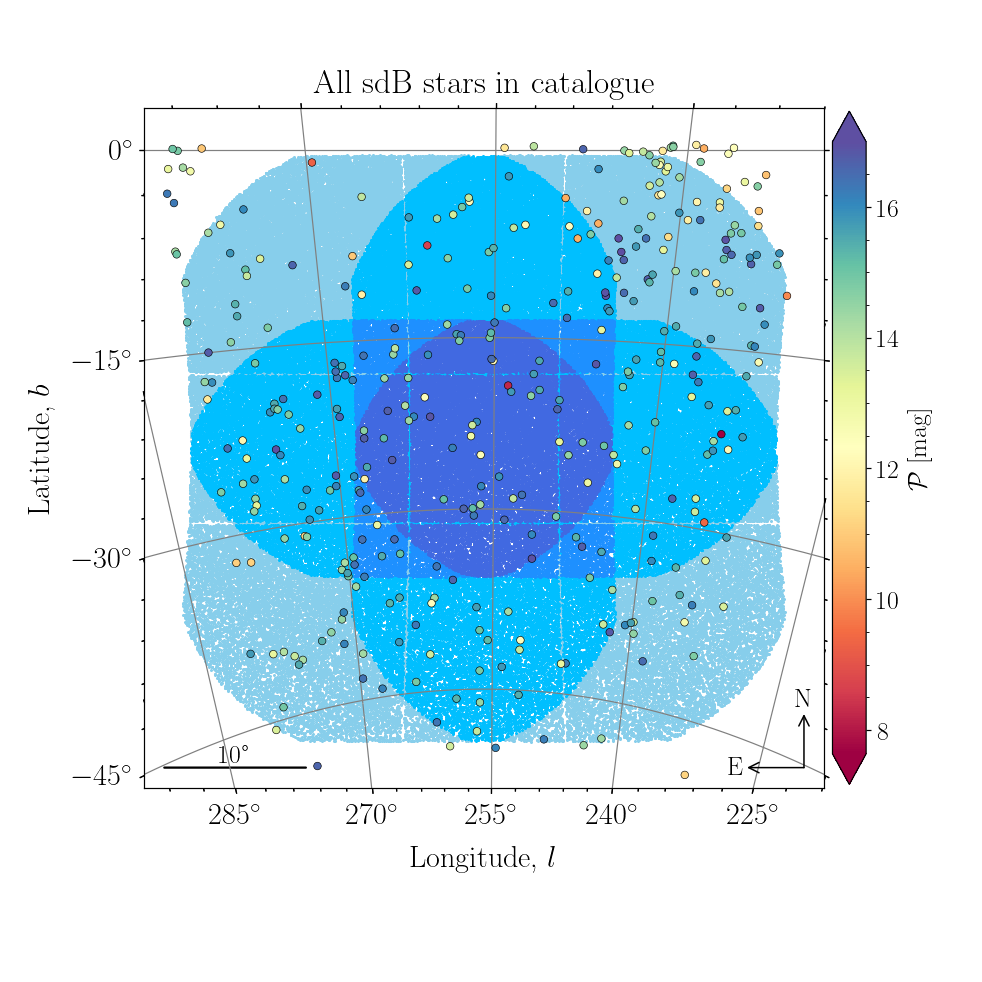

In [5]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=df.ra, decStars=df.dec, c=df.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='All sdB stars in catalogue', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_all.png', bbox_inches='tight', dpi=200)

### Cross-match with LOPS2 N-CAM sources

In [6]:
# Load PLATO-CS catalogue
df_ncam = pd.read_feather(hdir / 'PlatoCS_NCAM_LOPS2.ftr')
df_ncam

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,R_upp,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam
0,4677205714465503104,69.189319,-62.077491,272.671893,-39.342582,1.448518,3.785840,0.560105,1.958775,3.770394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
1,5300300156538723328,139.272369,-59.275176,278.459062,-7.011166,2.037026,2.179420,1.859075,2.213786,0.552959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
2,5605797194566011520,111.023738,-29.303083,242.616496,-6.485724,2.335989,2.418159,2.227041,2.450408,0.339532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
3,5610441600394646016,105.429755,-27.934809,239.168820,-10.273803,2.369039,3.053957,1.819715,2.760549,1.768627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K,<NA>,6
4,5310393535853560576,140.528323,-55.010611,275.882156,-3.537435,2.402990,2.461229,2.323981,2.487886,0.246693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28358166,5552052752651976448,98.708509,-47.968412,256.668424,-22.446870,19.122396,19.035864,19.253256,18.963625,-0.416525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24
28358167,5502633106599013504,97.339259,-51.308448,259.930923,-24.168748,19.132614,19.019403,19.305698,18.920208,-0.553066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24
28358168,5550978254914286080,97.182171,-50.181887,258.707380,-23.992113,19.142763,19.054300,19.276663,18.980139,-0.426327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24
28358169,5504630816145172480,105.088998,-51.963487,262.076591,-19.743369,19.168743,19.073547,19.313267,18.992630,-0.460617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24


In [7]:
# Cross-match with catalogues
dt_ncam = df[df['source_id'].isin(df_ncam['gaiaDR3'])].sort_values(by='source_id').reset_index(drop=True)
ds_ncam = df_ncam[df_ncam['gaiaDR3'].isin(dt_ncam['source_id'])].sort_values(by='gaiaDR3').reset_index(drop=True)

In [8]:
# Columns from Gaia DR3 catalogue
dt_ncam['Pmag']  = ds_ncam.Pmag
dt_ncam['PBmag'] = ds_ncam.PBmag
dt_ncam['PRmag'] = ds_ncam.PRmag
dt_ncam['ncam']  = ds_ncam.ncam
dt_ncam

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b,Pmag,PBmag,PRmag,ncam
0,GaiaDR32883459794914510848,2883459794914510848,88.649860,-39.622882,13.003768,-0.201273,1.307256,0.021290,245.739950,-27.327127,13.078784,13.035642,13.142443,24
1,GaiaDR32884197365355701888,2884197365355701888,91.172064,-37.020603,13.845441,-0.052500,0.428231,0.017235,243.516716,-24.739499,13.864581,13.853014,13.881262,12
2,GaiaDR32884425136061362560,2884425136061362560,90.136265,-36.880758,12.880259,-0.073231,0.676734,0.020932,243.114603,-25.495926,12.907047,12.890980,12.930301,12
3,GaiaDR32884846420813793152,2884846420813793152,92.348157,-37.660846,15.004970,-0.221174,0.762293,0.025362,244.482206,-24.024734,15.087615,15.040363,15.157524,24
4,GaiaDR32885564848583681152,2885564848583681152,93.937607,-35.249925,14.245788,-0.368056,0.853701,0.030642,242.402691,-22.079101,14.385525,14.308588,14.501327,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,TYC6542-2435-1,5616726679431972096,111.789756,-24.711766,12.007004,0.166950,1.443339,0.081297,238.863166,-3.733891,11.948569,11.987198,11.895200,6
339,GaiaDR35616854089648398976,5616854089648398976,110.271064,-24.965588,16.408417,0.276194,0.382719,0.042810,238.440738,-5.070477,16.313986,16.379696,16.225473,6
340,GaiaDR35617870863026356096,5617870863026356096,110.902311,-23.199929,12.995177,0.463454,2.517131,0.254262,237.143909,-3.737114,12.843602,12.959789,12.694600,6
341,TYC6537-3100-1,5617876047041466752,110.524302,-23.342556,11.697303,0.405783,0.946958,0.070841,237.107337,-4.110742,11.562693,11.662737,11.432340,6


<IPython.core.display.Javascript object>


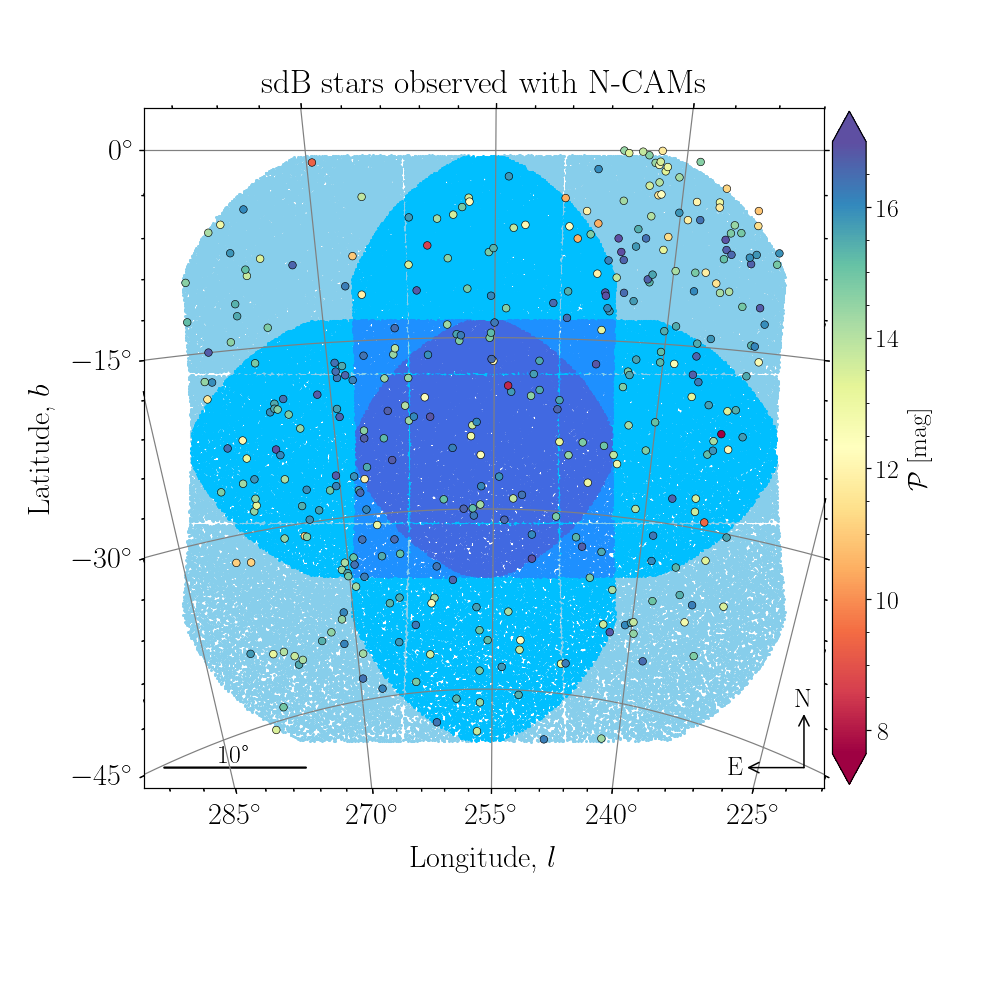

In [9]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt_ncam.ra, decStars=dt_ncam.dec, c=dt_ncam.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='sdB stars observed with N-CAMs', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_ncams.png', bbox_inches='tight', dpi=200)

NOTE: that the reason why there are some targets outside the LOPS2 FOV is because the Valerie selected all cross-matches from Anna's target list below $r_{\rm OA} < 19.6$ deg.

### Cross-match with LOPS2 F-CAM sources

In [10]:
# Load PLATO-CS catalogue
df_fcam = pd.read_feather(hdir / 'PlatoCS_FCAM_LOPS2.ftr')
df_fcam.gaiaDR3 = df_fcam.gaiaDR3.astype('int64')
df_fcam

,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,pmdec,...,S_err,spec,evol,variable,class,ncams,Pmag,Pgiant,PBmag,PRmag
0,5502164890740285696,102.484267,-50.614848,2.618499,1.312425,NaN,18.757713,0.347519,32.618184,-69.565734,...,NaN,G,<NA>,NOT_AVAILABLE,,6,2.282788,2.277100,2.718279,1.864839
1,2896572746685604480,95.078337,-30.063349,3.007651,0.069759,NaN,9.492206,0.447933,6.084451,4.247413,...,NaN,B,<NA>,NOT_AVAILABLE,,6,2.982762,2.982928,2.998538,2.960518
2,5478862906452936960,102.047058,-61.940116,3.203374,0.458191,NaN,NaN,NaN,NaN,NaN,...,NaN,A,<NA>,NOT_AVAILABLE,,6,3.053324,3.053446,3.168014,2.906023
3,5557271829408912896,99.440299,-43.195953,3.175233,0.098825,NaN,8.819389,0.288251,-0.537264,-3.858982,...,NaN,B,<NA>,NOT_AVAILABLE,,6,3.140169,3.140392,3.162667,3.108633
4,4757601523650165120,83.406311,-62.489769,3.593462,1.049574,0.3925,2.930785,0.139114,-0.611187,12.949733,...,NaN,F,<NA>,NOT_AVAILABLE,,6,3.302200,3.298827,3.620285,2.965348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595689,4756152710941311616,86.200359,-64.625596,16.997581,-0.231808,0.0134,0.062691,0.052648,1.624275,0.597684,...,NaN,B,<NA>,NOT_AVAILABLE,,6,17.084316,17.083603,17.034878,17.157562
1595690,4799881521014158976,80.493380,-45.189834,16.944908,-0.415487,0.0060,0.390238,0.048283,10.400172,0.405075,...,NaN,O,<NA>,NOT_AVAILABLE,,6,17.103271,17.102135,17.016943,17.233809
1595691,4806300199316094208,82.480514,-41.540082,16.956432,-0.461933,NaN,2.805125,0.051731,4.176935,-5.611352,...,NaN,O,<NA>,NOT_AVAILABLE,,6,17.133062,17.131897,17.037609,17.277994
1595692,4810897257431722368,76.098241,-43.974226,16.973370,-0.553024,NaN,2.175653,0.057416,6.909746,44.610506,...,NaN,O,<NA>,NOT_AVAILABLE,,6,17.185759,17.184683,17.072557,17.358831


In [11]:
# Cross-match with catalogues
dt_fcam = df[df['source_id'].isin(df_fcam['gaiaDR3'])].reset_index(drop=True)
dt_fcam

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b
0,GaiaDR35572926710324060928,5572926710324060928,92.130599,-40.817173,14.491826,-0.330461,0.851083,0.023350,247.768369,-25.051994
1,GaiaDR35573125962446736384,5573125962446736384,93.218767,-39.381490,14.768272,-0.413017,0.722396,0.030862,246.499027,-23.860810
2,GaiaDR35577647154260869248,5577647154260869248,101.124488,-36.537021,16.856806,-0.249401,0.530204,0.050328,245.791846,-17.044635
3,TYC8076-1235-1,4789836284000445568,70.735411,-46.160875,12.275810,-0.075267,0.743688,0.022091,251.871680,-41.047829
4,GaiaDR34792844272935841792,4792844272935841792,87.780025,-50.686608,16.618168,-0.355936,0.354133,0.046551,258.010160,-29.965904
...,...,...,...,...,...,...,...,...,...,...
86,GaiaDR35498415349929663104,5498415349929663104,101.879017,-53.542556,14.367732,-0.410192,0.738307,0.027197,263.055629,-22.073550
87,GaiaDR35477301943538453632,5477301943538453632,95.691516,-63.561117,15.957672,-0.478599,0.512455,0.039719,273.138615,-27.241188
88,GaiaDR35494547955217871360,5494547955217871360,92.996346,-59.264747,16.528084,-0.495090,0.391568,0.044315,268.153859,-28.024472
89,GaiaDR35510452287837529600,5510452287837529600,109.421833,-46.862997,14.771426,-0.280308,0.244569,0.020853,258.175859,-15.259782


<IPython.core.display.Javascript object>


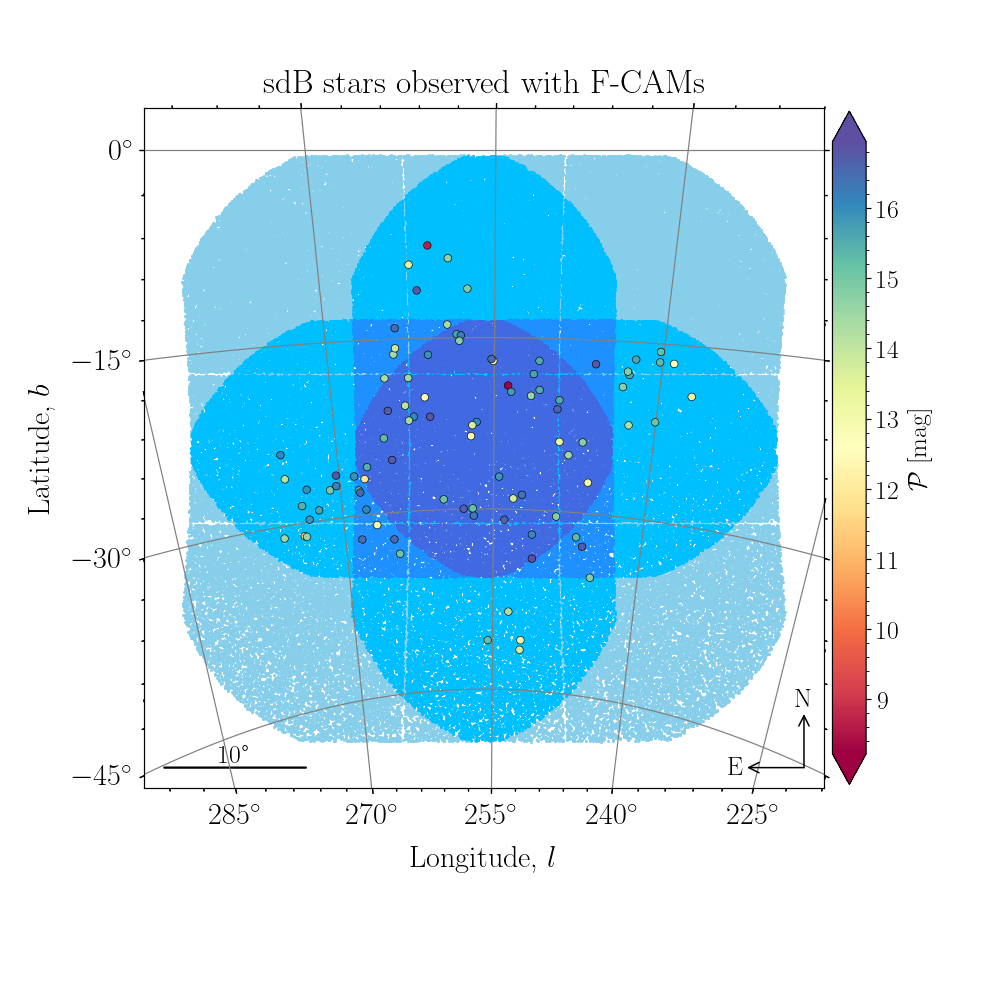

In [12]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt_fcam.ra, decStars=dt_fcam.dec, c=dt_fcam.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='sdB stars observed with F-CAMs ', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_fcams.png', bbox_inches='tight', dpi=200)

### Make combined N-CAM/F-CAM catalogue

In [13]:
# Copy over ncam data frame
dt = dt_ncam.copy().reset_index(drop=True)

In [14]:
# Add boolen fcam colun
dt['fcam'] = dt_ncam['source_id'].isin(dt_fcam['source_id'])

In [16]:
# Sort after magnitude
dt = dt.sort_values(by=['ncam', 'phot_g_mean_mag']).reset_index(drop=True)
dt

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b,Pmag,PBmag,PRmag,ncam,fcam
0,HD78401,5326745919424790656,136.577897,-48.628579,9.295487,0.126412,2.009157,0.054582,269.577304,-0.897133,9.250877,9.279842,9.210508,6,False
1,GaiaDR32905446114757379840,2905446114757379840,83.115605,-30.554629,9.412152,-0.246340,1.028378,0.031474,234.463253,-29.387189,9.504489,9.452074,9.582291,6,False
2,CD-314800,5592257426113535104,114.125677,-32.211956,10.467565,-0.490885,4.728634,0.046518,246.459055,-5.506064,10.655580,10.554465,10.809466,6,False
3,TYC5977-1246-1,2929905678637186688,108.915360,-20.861382,10.889847,0.067386,1.431783,0.172918,234.210102,-4.280677,10.865794,10.881024,10.844309,6,False
4,TYC8161-1329-1,5322521179137882240,125.432323,-51.054212,10.949416,0.305516,1.168120,0.095404,267.044482,-8.041750,10.845650,10.918906,10.747681,6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,GaiaDR35485330440005020544,5485330440005020544,104.303655,-54.976163,16.713818,-0.298504,0.392695,0.046701,264.972443,-21.133244,16.826376,16.763367,16.920498,24,True
339,GaiaDR35484435197022249216,5484435197022249216,101.486187,-57.696962,16.732193,-0.195238,0.292108,0.046608,267.338609,-23.378985,16.804901,16.763010,16.866663,24,False
340,1RXSJ062737.8-555700,5496278341705187968,96.908516,-55.951076,16.747830,-0.350863,0.509236,0.041419,264.860081,-25.434101,16.880829,16.807318,16.991280,24,True
341,GaiaDR35501837854749153024,5501837854749153024,101.431944,-51.680234,16.875198,-0.422529,0.398762,0.047215,261.046981,-21.807877,17.036331,16.948614,17.169052,24,True


In [20]:
# Store the number of stars
N = dt.shape[0]

In [19]:
# # Plot target in Galactic projection
# dx = dt[dt.ncam == 6]
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', fovSize=30, ncamStars=True,
#     raStars=dx.ra, decStars=dx.dec, c=dx.phot_g_mean_mag,
#     clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
#     title='sdB stars observed with N-CAMs', figsize=(9,9),
# )

### Run Platonium to get SPR

In [22]:
# Rename column in order to match catalogues
dx = dt.copy()
dx = dx.rename(columns={'source_id':'gaiaDR3'})

In [23]:
# Create target catalogue
dx.reset_index(drop=True, inplace=True)
dx.to_feather(idir / f'starcat_hotsd_targets.ftr')

In [24]:
# Create contaminant catalogue
dc = ut.getContaminants(dx, df_ncam, column='gaiaDR3')
dc.to_feather(idir / f'starcat_hotsd_contaminants.ftr')

100%|██████████████████████████████████████████████████| 343/343 [00:49<00:00,  6.95it/s]                                                                                                                          


In [25]:
# Create an parameterisation file
from platosim.slurm import getParamFile
getParamFile(range(1,N+1), range(1,5), range(1,7), range(1,2), ofile=idir / 'cluster.data');

In [26]:
# Run simulation for only 1 exposure across all cameras
from platosim.hpc import HPC
hpc = HPC('go_hotsd_pulsators', cpus=1)
hpc.run(script='platonium', param_file='cluster.data', odir=odir, kwargs='--nexp 1 -w -v 0')

100%|██████████████████████████████████████████████████| 8232/8232 [7:43:57<00:00,  3.38s/it]                                                                                                                      


### Add simulation info to main catalogue

In [34]:
# Fetch extra parameters from simulation tables
ncon = np.zeros(N) 
SPR = np.zeros(N)
NSR = np.zeros(N)
for i in range(1, N+1):
    star = f'{i}'.zfill(9)
    lcs = LightCurve(odir/star, mode='multi')
    # Create table with simulation statistics
    if lcs.files() is not None:
        dt_sims = lcs.stat_sim_table(ofile=odir/f'table_{star}.ftr', clean=False, verbose=False)
        ncon[i-1] = dt_sims.ncon.iloc[0]
        SPR[i-1]  = dt_sims.SPR.mean()
        NSR[i-1]  = dt_sims.NSR.mean()
    else:
        ncon[i-1] = None
        SPR[i-1]  = None
        NSR[i-1]  = None
dx = dx[dx.SPR.isna()]
dx

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000004
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000008
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000010
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000013
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000023
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000033
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000049
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hotsd_pulsators/output/000000063


,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b,Pmag,PBmag,PRmag,ncam,fcam,ncon,SPR,NSR
3,TYC5977-1246-1,2929905678637186688,108.915360,-20.861382,10.889847,0.067386,1.431783,0.172918,234.210102,-4.280677,10.865794,10.881024,10.844309,6,False,NaN,NaN,NaN
7,TYC5978-356-1,5619525761158363776,111.678169,-22.402210,11.191152,0.277905,0.410089,0.055143,236.777250,-2.730195,11.096172,11.162319,11.007108,6,False,NaN,NaN,NaN
9,TYC5976-2584-1,2928427282175326848,107.808497,-21.231946,11.380672,0.110069,1.232582,0.043779,234.066087,-5.368727,11.341704,11.366828,11.306569,6,False,NaN,NaN,NaN
12,GaiaDR35614312912124661632,5614312912124661632,116.964425,-25.567934,11.675820,0.242297,2.524846,0.427929,241.901365,-0.065545,11.592357,11.649493,11.514764,6,False,NaN,NaN,NaN
22,LS1274,5306775455393745024,139.733370,-57.073757,12.844605,-0.317878,1.466096,0.032085,277.038728,-5.304914,12.964712,12.897802,13.064881,6,False,NaN,NaN,NaN
32,GALEXJ03271-6352,4673903262571474688,51.792237,-63.881740,13.424819,-0.333533,1.583088,0.027131,279.651561,-45.577131,13.551040,13.480990,13.656092,6,False,NaN,NaN,NaN
48,GaiaDR35306460101714855552,5306460101714855552,140.264165,-58.147077,14.207313,-0.160043,0.894391,0.020232,278.007836,-5.854964,14.266627,14.232077,14.317311,6,False,NaN,NaN,NaN
62,GaiaDR35298790149103579904,5298790149103579904,138.138147,-62.291845,14.622718,-0.096154,0.466722,0.023073,280.298552,-9.479457,14.658019,14.637014,14.688530,6,False,NaN,NaN,NaN
63,GaiaDR35615740696686130816,5615740696686130816,114.619868,-23.415985,14.663765,0.485325,2.455133,0.161802,238.973083,-0.845269,14.505907,14.628366,14.349831,6,False,NaN,NaN,NaN
70,GaiaDR32932072884778813440,2932072884778813440,104.259739,-20.830782,14.897368,-0.219981,0.730943,0.029735,232.215291,-8.153478,14.979556,14.932549,15.049090,6,False,NaN,NaN,NaN


<IPython.core.display.Javascript object>


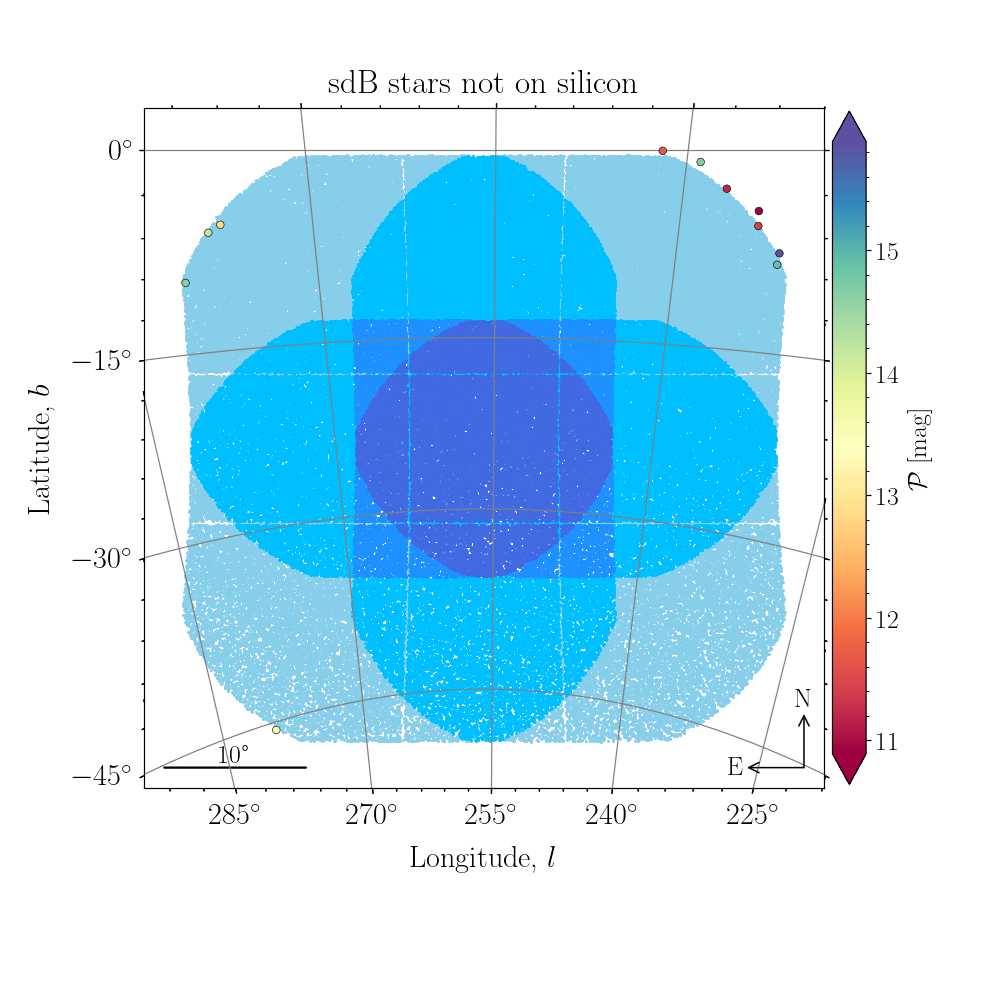

In [35]:
# Inspect the star not detected on silicon
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='sdB stars not on silicon', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_nosim.png', bbox_inches='tight', dpi=200)

In [36]:
# Columns from simulations
dt0 = dt.copy()
dt0['ncon'] = ncon
dt0['SPR']  = SPR
dt0['NSR']  = NSR
dt0

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b,Pmag,PBmag,PRmag,ncam,fcam,ncon,SPR,NSR
0,HD78401,5326745919424790656,136.577897,-48.628579,9.295487,0.126412,2.009157,0.054582,269.577304,-0.897133,9.250877,9.279842,9.210508,6,False,2.0,0.235091,0.001507
1,GaiaDR32905446114757379840,2905446114757379840,83.115605,-30.554629,9.412152,-0.246340,1.028378,0.031474,234.463253,-29.387189,9.504489,9.452074,9.582291,6,False,3.0,0.000400,0.001458
2,CD-314800,5592257426113535104,114.125677,-32.211956,10.467565,-0.490885,4.728634,0.046518,246.459055,-5.506064,10.655580,10.554465,10.809466,6,False,27.0,0.028212,0.002702
3,TYC5977-1246-1,2929905678637186688,108.915360,-20.861382,10.889847,0.067386,1.431783,0.172918,234.210102,-4.280677,10.865794,10.881024,10.844309,6,False,NaN,NaN,NaN
4,TYC8161-1329-1,5322521179137882240,125.432323,-51.054212,10.949416,0.305516,1.168120,0.095404,267.044482,-8.041750,10.845650,10.918906,10.747681,6,False,15.0,0.029585,0.002943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,GaiaDR35485330440005020544,5485330440005020544,104.303655,-54.976163,16.713818,-0.298504,0.392695,0.046701,264.972443,-21.133244,16.826376,16.763367,16.920498,24,True,2.0,0.000301,0.250830
339,GaiaDR35484435197022249216,5484435197022249216,101.486187,-57.696962,16.732193,-0.195238,0.292108,0.046608,267.338609,-23.378985,16.804901,16.763010,16.866663,24,False,3.0,0.003476,0.229469
340,1RXSJ062737.8-555700,5496278341705187968,96.908516,-55.951076,16.747830,-0.350863,0.509236,0.041419,264.860081,-25.434101,16.880829,16.807318,16.991280,24,True,2.0,0.538450,0.325005
341,GaiaDR35501837854749153024,5501837854749153024,101.431944,-51.680234,16.875198,-0.422529,0.398762,0.047215,261.046981,-21.807877,17.036331,16.948614,17.169052,24,True,2.0,0.003044,0.281666


In [39]:
# Save catalogue
dt0.reset_index(drop=True).to_csv(ddir / 'Plato_hot_subdwarf_star_catalogue.csv', index=False)

## Check missing stars against CfP tool

In [24]:
dt = pd.read_csv(ddir / 'gaia_targets_pmag.csv', sep=';')
dt['gaiaDR3'] = [f'Gaia DR3 {i}' for i in dt.Gaia_ID]
dt.head()

,Gaia_ID,RA_deg,Dec_deg,Pmag,gaiaDR3
0,2929905678637186688,108.915360,-20.861382,10.865794,Gaia DR3 2929905678637186688
1,5619525761158363776,111.678169,-22.402210,11.096172,Gaia DR3 5619525761158363776
2,2928427282175326848,107.808497,-21.231946,11.341704,Gaia DR3 2928427282175326848
3,5614312912124661632,116.964425,-25.567934,11.592357,Gaia DR3 5614312912124661632
4,4673903262571474688,51.792237,-63.881740,13.551040,Gaia DR3 4673903262571474688


In [21]:
# Load in PIC210 contaminant table
ds = pd.read_feather(hdir / 'PlatoGO_PIC210_LOPS2.ftr')

In [25]:
# Cross-match with catalogues
dt0 = dt[dt['gaiaDR3'].isin(ds['gaiaDR3'])]
dt0

,Gaia_ID,RA_deg,Dec_deg,Pmag,gaiaDR3
0,2929905678637186688,108.915360,-20.861382,10.865794,Gaia DR3 2929905678637186688
1,5619525761158363776,111.678169,-22.402210,11.096172,Gaia DR3 5619525761158363776
2,2928427282175326848,107.808497,-21.231946,11.341704,Gaia DR3 2928427282175326848
3,5614312912124661632,116.964425,-25.567934,11.592357,Gaia DR3 5614312912124661632
4,4673903262571474688,51.792237,-63.881740,13.551040,Gaia DR3 4673903262571474688
5,5306460101714855552,140.264165,-58.147077,14.266627,Gaia DR3 5306460101714855552
6,5298790149103579904,138.138147,-62.291845,14.658019,Gaia DR3 5298790149103579904
7,5615740696686130816,114.619868,-23.415985,14.505907,Gaia DR3 5615740696686130816
8,2932072884778813440,104.259739,-20.830782,14.979556,Gaia DR3 2932072884778813440
9,2932101197203707136,105.068889,-20.447484,15.726169,Gaia DR3 2932101197203707136


<IPython.core.display.Javascript object>


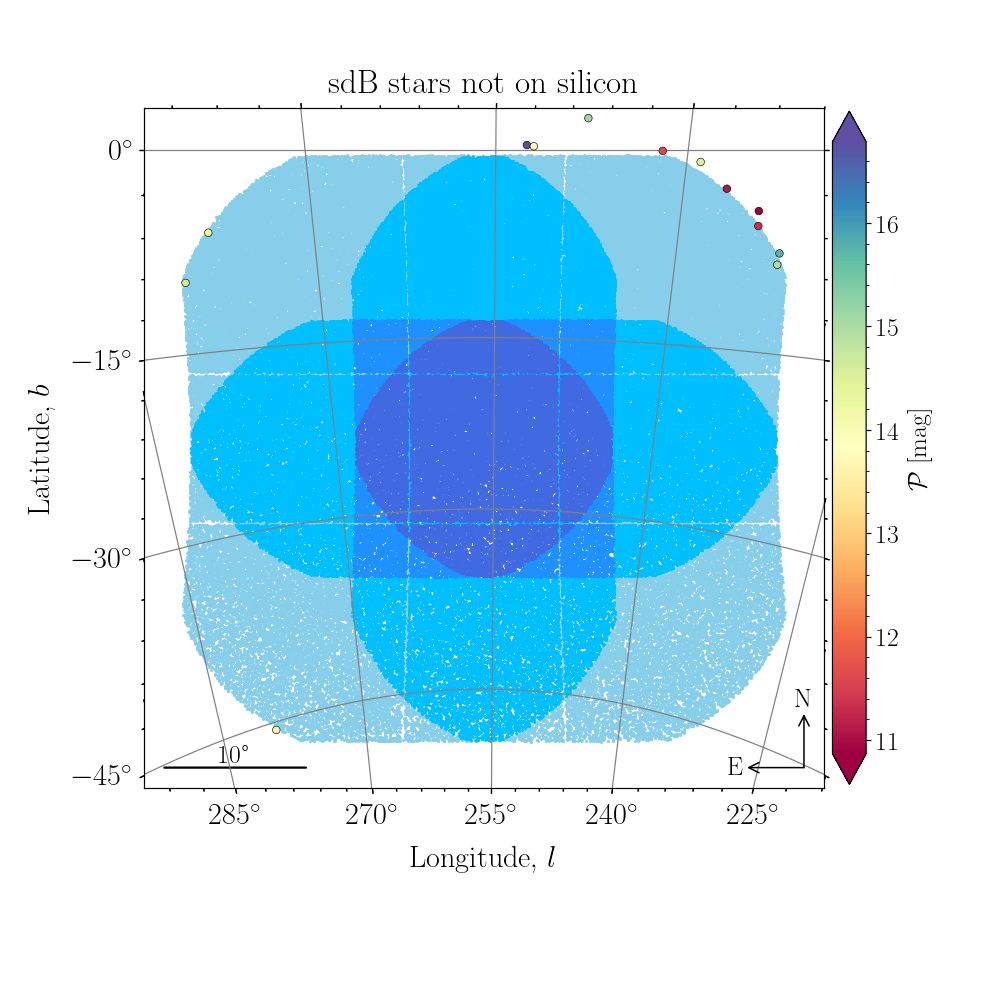

In [27]:
# Inspect the star not detected on silicon
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt0.RA_deg, decStars=dt0.Dec_deg, c=dt0.Pmag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='sdB stars not on silicon', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_notInPICcon210.png', bbox_inches='tight', dpi=200)